In [8]:
import pandas as pd #read data from the dataset
import matplotlib.pyplot as plt #for visualizaation
import numpy as np 
%matplotlib inline
#Renders plots inside the notebook output cell
#Converts figures into static images (PNG)
#Automatically calls plt.show() after each cell
#Without it plots open in separate UI window

In [9]:
df = pd.read_csv('height-weight.csv')

In [10]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


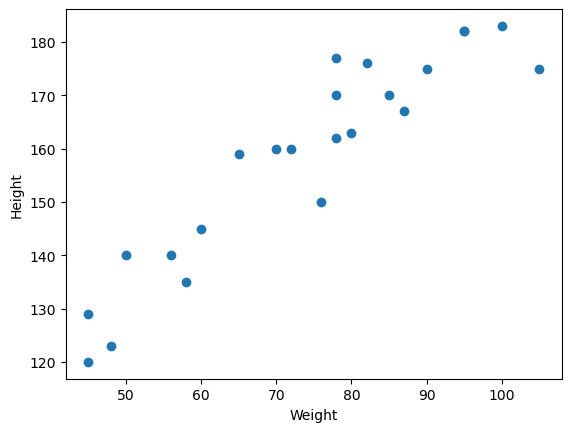

In [14]:
#Scatter plot 
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [16]:
#fining corelation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [ ]:
import seaborn as sns
#sns.pairplot visualizes pairwise relationships and individual feature distributions to quickly reveal
#correlations, patterns, and data structure in a dataset.

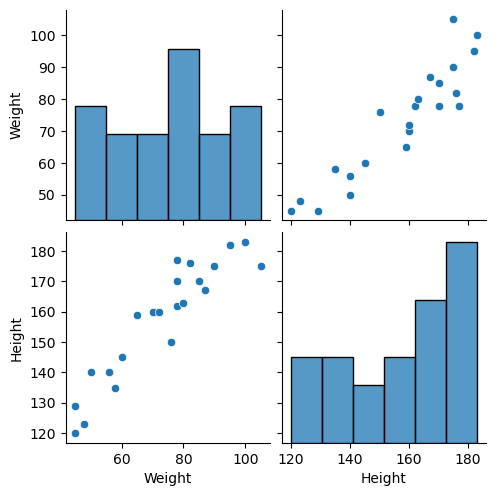

In [24]:
sns.pairplot(df)
plt.show()

In [34]:
#Step 1 : Divide features into Dependent and Independent features
X = df[['Weight']] #always make sure indepedent variable is Datafrme or 2D Array
X.head()
np.array(X).shape

(23, 1)

In [36]:
Y = df['Height'] #Dependent feature and must be in series for m or 1D Aray
np.array(Y).shape

(23,)

In [ ]:
X_series = df['Weight'] #it is 1D Array
np.array(X_series).shape  #train with this as well to know why it is not recommended

(23,)

In [25]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [37]:
#Train test Split
from sklearn.model_selection import train_test_split

In [39]:
#
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25, random_state=42)

In [40]:
x_train.shape

(17, 1)

In [41]:
##Standardization -> To make units same so that the convergence takes less time 
#for  this we create Z-Test with mean = 0, SD = 1 Z-score = (xi - mu) / SD

from sklearn.preprocessing import StandardScaler

In [43]:
#Applying to inpuit feature
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)

In [44]:
#fit_transform() uses mean = 0 and SD = 1 but when we apply on test data we use transform() and this 
#tansform() uses training data's mean and SD for validation
#it is done to prevent data leakage | we dont want that training data know any data about test daata
x_test = scalar.transform(x_test)

In [45]:
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [49]:
#Applying Simple linear regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)

In [50]:
regression.fit(X_series, Y) ##when the series or 1D array is given 

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [52]:
regression.fit(x_train, y_train) #train is 2D Array

LinearRegression(n_jobs=-1)

In [ ]:
regression.coef_ #it is beta1
#it describes one unit wieight movement cause 17 unit height change 


array([17.2982057])

In [ ]:
regression.intercept_ #intercept
#when wight is 0 where the height is met 

np.float64(156.47058823529412)

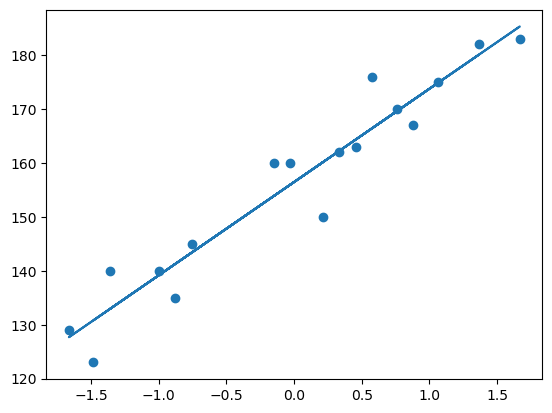

In [63]:
#plot training data best fit line
plt.scatter(x_train, y_train)
plt.plot(x_train, regression.predict(x_train))
plt.show()

##Prdiction of test data
1. Predicted height = intercept + coef * weights
2. y_predicted = 156.470 + 17.29 * (x-test)

In [65]:
#Prediction for Test Data
y_predicted = regression.predict(x_test)

In [66]:
##performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [67]:
mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


In [68]:
## R squared error r^2 = 1 - SSR / SST
from sklearn.metrics import r2_score

In [69]:
score = r2_score(y_test, y_predicted)
print(score)

0.7360826717981276


In [70]:
##adjucted r^2
# Adj R^2 = [(1 - r2) * (n - 1) / (n - k - 1)]
ad_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)
print(ad_r2)

0.6701033397476595


In [71]:
##using OLS Linear Regression
import statsmodels.api as sm

In [72]:
model = sm.OLS(y_train, x_train).fit()

In [73]:
prediction = model.predict(x_test)

In [74]:
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [76]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 19 Apr 2026   Prob (F-statistic):                       0.664
Time:                        00:44:33   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\sumit-dev\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [77]:
##Prediction for new data
regression.predict([[72]])

array([1401.94139895])

In [78]:
regression.predict(scalar.transform([[72]]))  #make sure that the data to be predicted is standardized

c:\Users\sumit-dev\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])